# 10. Query Feature Bridge

## 1. 분석 목적과 경계

지금까지의 분석은 특정 향수와 비슷한 향수를 찾는 Perfume-to-Perfume Retrieval을 다뤘다. Retrieval
(많은 후보 중 관련 있어 보이는 항목을 찾아오는 과정)과 달리 실제 서비스의 입력은 사용자의 자연어다.

이번 Notebook의 질문은 다음과 같다.

> 사용자의 자연어 표현을 현재 데이터의 Accord / Note / Season / Daypart로 어디까지 근거 있게 표현할 수 있는가?

이 Notebook은 자연어 추천기를 구현하거나 추천 성능을 평가하지 않는다. `accords`, `accord strength`,
`notes`, `seasons`, `daypart`만 이용해 **Natural Language → Perfume Feature** 연결 구조의 데이터 근거를 만든다.

분석 원칙은 다음과 같다.

- 같은 향수 안의 중복 Accord와 Note는 한 번만 존재한 것으로 센다.
- Top / Middle / Base / Flat Note는 향수별 Union Note(위치를 합치고 중복을 제거한 Note 집합)로 사용한다.
- 사람의 직관으로 감각어나 장면 표현을 Accord에 배정하지 않는다.
- 데이터로 입증할 수 없는 관계는 `EXTERNAL_MAPPING_REQUIRED`로 남긴다.
- `reminds_me_of`, `similar.also_liked`, popularity 기반 추천, Final Holdout은 사용하지 않는다.
- LLM 호출, Embedding 생성, Machine Learning 학습·clustering, Golden Set 생성, 추천 정확도 계산을 하지 않는다.


## 2. 환경 설정

원본 중첩 구조와 Note 이름을 보존하기 위해 `perfumes.jsonl`을 기준 데이터로 사용한다. CSV의 구분 문자는
실제 Note 이름 안에도 들어갈 수 있으므로 이 분석의 기준 파일로 삼지 않는다. 모든 표는 재현성을 위해
정렬 기준과 동률 처리 순서를 고정한다.


In [1]:
import array
import collections
import itertools
import json
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 110)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

work_dir = pathlib.Path.cwd()
jsonl_path = work_dir / "perfumes.jsonl"
output_dir = work_dir / "analysis_outputs"
output_dir.mkdir(exist_ok=True)

if not jsonl_path.is_file():
    raise FileNotFoundError(
        "perfumes.jsonl을 찾을 수 없습니다. Notebook을 프로젝트 루트에서 실행하세요."
    )

SEASONS = ("winter", "spring", "summer", "autumn")
DAYPARTS = ("day", "night")

print(f"입력: {jsonl_path} ({jsonl_path.stat().st_size / 1024**2:,.2f} MB)")
print(f"출력 디렉터리: {output_dir}")


입력: c:\Users\SSAFY\Desktop\archive\perfumes.jsonl (485.94 MB)
출력 디렉터리: c:\Users\SSAFY\Desktop\archive\analysis_outputs


## 3. JSONL 1회 스트리밍과 공통 전처리

각 향수에서 분석에 필요한 Accord 존재·strength, Union Note, 유효 Season/Daypart share만 수집한다.
Season과 Daypart는 총 투표가 20 이상일 때만 비율을 계산한다. 각 향수의 share를 먼저 만든 뒤 향수별로
동일 가중 평균하므로, 투표 수가 매우 많은 인기 향수 하나가 전체 관계를 지배하지 않는다.

Accord strength 중복이 있으면 같은 향수 안에서 가장 큰 유효 값을 사용한다. 존재 빈도는 strength 결측과
무관하게 이름이 있는 Accord를 센다.


In [2]:
accord_to_index = {}
note_to_index = {}
accord_support = collections.Counter()
note_support = collections.Counter()
accord_strength_values = collections.defaultdict(lambda: array.array("f"))

# (accord_ids, note_ids, season_share_or_none, daypart_share_or_none)
compact_records = []
season_eligible_count = 0
daypart_eligible_count = 0

with jsonl_path.open("r", encoding="utf-8") as file:
    for line in file:
        if not line.strip():
            continue

        record = json.loads(line)

        # 향수 내부 Accord 중복 제거. strength는 유효 값 중 최댓값을 보존한다.
        accord_strength_by_id = {}
        accord_presence_ids = set()
        for item in record.get("accords") or []:
            name = item.get("name")
            if not name:
                continue
            accord_id = accord_to_index.setdefault(name, len(accord_to_index))
            accord_presence_ids.add(accord_id)

            strength = item.get("strength")
            if strength is None:
                continue
            strength = float(strength)
            previous = accord_strength_by_id.get(accord_id)
            if previous is None or strength > previous:
                accord_strength_by_id[accord_id] = strength

        accord_ids = tuple(sorted(accord_presence_ids))
        accord_support.update(accord_ids)
        for accord_id, strength in accord_strength_by_id.items():
            accord_strength_values[accord_id].append(strength)

        # Top/Middle/Base/Flat을 합친 향수별 Union Note
        notes = record.get("notes") or {}
        tiered = notes.get("tiered") or {}
        note_names_in_perfume = set()
        for tier in ("top", "middle", "base"):
            note_names_in_perfume.update(
                item.get("name")
                for item in tiered.get(tier) or []
                if item.get("name")
            )
        note_names_in_perfume.update(
            item.get("name")
            for item in notes.get("flat") or []
            if item.get("name")
        )
        note_ids = tuple(sorted(
            note_to_index.setdefault(name, len(note_to_index))
            for name in note_names_in_perfume
        ))
        note_support.update(note_ids)

        seasons = record.get("seasons") or {}
        season_votes = np.asarray(
            [float(seasons.get(name, 0) or 0) for name in SEASONS],
            dtype=np.float64,
        )
        season_total = float(season_votes.sum())
        if season_total >= 20:
            season_share = tuple((season_votes / season_total).tolist())
            season_eligible_count += 1
        else:
            season_share = None

        daypart = record.get("daypart") or {}
        daypart_votes = np.asarray(
            [float(daypart.get(name, 0) or 0) for name in DAYPARTS],
            dtype=np.float64,
        )
        daypart_total = float(daypart_votes.sum())
        if daypart_total >= 20:
            daypart_share = tuple((daypart_votes / daypart_total).tolist())
            daypart_eligible_count += 1
        else:
            daypart_share = None

        compact_records.append((accord_ids, note_ids, season_share, daypart_share))

total_perfumes = len(compact_records)
accord_names = [None] * len(accord_to_index)
for name, index in accord_to_index.items():
    accord_names[index] = name
note_names = [None] * len(note_to_index)
for name, index in note_to_index.items():
    note_names[index] = name

load_summary = pd.Series({
    "전체 향수 수": total_perfumes,
    "고유 Accord 수": len(accord_names),
    "고유 Union Note 수": len(note_names),
    "Season total >= 20 향수 수": season_eligible_count,
    "Daypart total >= 20 향수 수": daypart_eligible_count,
    "Accord presence 총합": sum(accord_support.values()),
    "Union Note presence 총합": sum(note_support.values()),
}, name="count")
display(load_summary.to_frame())

assert total_perfumes > 0
assert len(accord_names) > 0 and len(note_names) > 0


,count
전체 향수 수,131930
고유 Accord 수,92
고유 Union Note 수,2523
Season total >= 20 향수 수,57533
Daypart total >= 20 향수 수,44421
Accord presence 총합,1000570
Union Note presence 총합,1091811


## 4. Accord 전체 사전

표준편차(값들이 평균 주변에 얼마나 퍼져 있는지를 나타내는 값)는 전체 코퍼스를 분석하므로 모집단
표준편차 `ddof=0`으로 계산한다. 빈도는 같은 향수 안에서 Accord가 여러 번 나타나더라도 한 번만 센다.


In [3]:
accord_dictionary_rows = []
for accord_id, accord in enumerate(accord_names):
    strengths = np.asarray(
        accord_strength_values.get(accord_id, array.array("f")),
        dtype=np.float64,
    )
    accord_dictionary_rows.append({
        "accord": accord,
        "perfume_count": int(accord_support[accord_id]),
        "perfume_share": accord_support[accord_id] / total_perfumes,
        "strength_observation_count": int(len(strengths)),
        "mean_strength": float(strengths.mean()) if len(strengths) else np.nan,
        "median_strength": float(np.median(strengths)) if len(strengths) else np.nan,
        "strength_std": float(strengths.std(ddof=0)) if len(strengths) else np.nan,
    })

accord_dictionary_df = (
    pd.DataFrame(accord_dictionary_rows)
    .sort_values(["perfume_count", "accord"], ascending=[False, True])
    .reset_index(drop=True)
)
accord_dictionary_df.to_csv(
    output_dir / "10_accord_dictionary.csv", index=False, encoding="utf-8-sig"
)

print(f"실제 Accord 수: {len(accord_dictionary_df):,}")
display(accord_dictionary_df)


실제 Accord 수: 92


,accord,perfume_count,perfume_share,strength_observation_count,mean_strength,median_strength,strength_std
0,woody,81432,0.617236,81432,65.828360,65.000000,27.441517
1,powdery,62885,0.476654,62885,48.343150,45.000000,24.503863
2,sweet,60625,0.459524,60625,54.332833,50.000000,27.194537
3,citrus,59969,0.454552,59969,67.283046,67.000000,28.644740
4,aromatic,54606,0.413901,54606,56.065597,53.000000,27.889844
5,fresh spicy,47271,0.358304,47271,51.155867,48.000000,25.719203
6,floral,46586,0.353111,46586,56.229189,51.000000,29.626219
7,amber,45478,0.344713,45478,61.021549,57.000000,26.701265
8,warm spicy,45319,0.343508,45319,57.098281,52.000000,26.427397
9,fruity,43222,0.327613,43222,64.469044,64.000000,28.249935


## 5. Note 전체 사전

IDF(Inverse Document Frequency; 너무 흔한 Note의 중요도를 낮추고 희귀한 Note의 중요도를 높이는 값)는
기존 분석과 동일한 smoothing 공식을 사용한다.

\[
IDF(n)=\log\left(\frac{N+1}{df(n)+1}\right)+1
\]

`df(n)`은 Note가 등장한 향수 수다. 등장 향수 10개 이상인 Note만 주 분석 대상으로 표시하며, IDF 상위
100개도 이 안정성 조건 안에서 고른다. 전체 사전은 재현과 검증을 위해 추가 CSV로 저장한다.


In [4]:
note_dictionary_rows = []
for note_id, note in enumerate(note_names):
    frequency = int(note_support[note_id])
    note_dictionary_rows.append({
        "note": note,
        "perfume_count": frequency,
        "perfume_share": frequency / total_perfumes,
        "idf": float(np.log((total_perfumes + 1) / (frequency + 1)) + 1),
        "main_analysis_eligible": bool(frequency >= 10),
    })

note_dictionary_df = (
    pd.DataFrame(note_dictionary_rows)
    .sort_values(["perfume_count", "note"], ascending=[False, True])
    .reset_index(drop=True)
)
note_dictionary_df.to_csv(
    output_dir / "10_note_dictionary.csv", index=False, encoding="utf-8-sig"
)

top_100_notes = note_dictionary_df.head(100).copy()
high_idf_100_notes = (
    note_dictionary_df[note_dictionary_df["main_analysis_eligible"]]
    .sort_values(["idf", "perfume_count", "note"], ascending=[False, True, True])
    .head(100)
    .reset_index(drop=True)
)

print(f"전체 고유 Note 수: {len(note_dictionary_df):,}")
print(f"등장 향수 >= 10인 주 분석 Note 수: {note_dictionary_df['main_analysis_eligible'].sum():,}")
display(Markdown("### 빈도 상위 Note 100개"))
display(top_100_notes)
display(Markdown("### 주 분석 Note 중 IDF 상위 100개"))
display(high_idf_100_notes)


전체 고유 Note 수: 2,523
등장 향수 >= 10인 주 분석 Note 수: 1,416


### 빈도 상위 Note 100개

,note,perfume_count,perfume_share,idf,main_analysis_eligible
0,Musk,49244,0.373259,1.985471,True
1,Amber,36671,0.277958,2.280266,True
2,Bergamot,36337,0.275426,2.289415,True
3,Vanilla,35628,0.270052,2.309119,True
4,Sandalwood,34292,0.259926,2.347338,True
5,Jasmine,33686,0.255332,2.365167,True
6,Patchouli,32473,0.246138,2.401839,True
7,Rose,27804,0.210748,2.557063,True
8,Cedar,22305,0.169067,2.777423,True
9,Vetiver,17674,0.133965,3.010128,True


### 주 분석 Note 중 IDF 상위 100개

,note,perfume_count,perfume_share,idf,main_analysis_eligible
0,Amazon Lily,10,0.000076,10.392139,True
1,Assam Tea,10,0.000076,10.392139,True
2,Beer/Ale,10,0.000076,10.392139,True
3,Blackberry Blossom,10,0.000076,10.392139,True
4,Caffè Latte,10,0.000076,10.392139,True
5,Caipirinha,10,0.000076,10.392139,True
6,Canadian Pine,10,0.000076,10.392139,True
7,Chalood Bark,10,0.000076,10.392139,True
8,Cherimoya,10,0.000076,10.392139,True
9,China Rose,10,0.000076,10.392139,True


## 6. Accord·Note 빈도 시각화

아래 두 그래프는 전체 향수 중 각 Feature가 존재하는 향수 수를 보여준다.


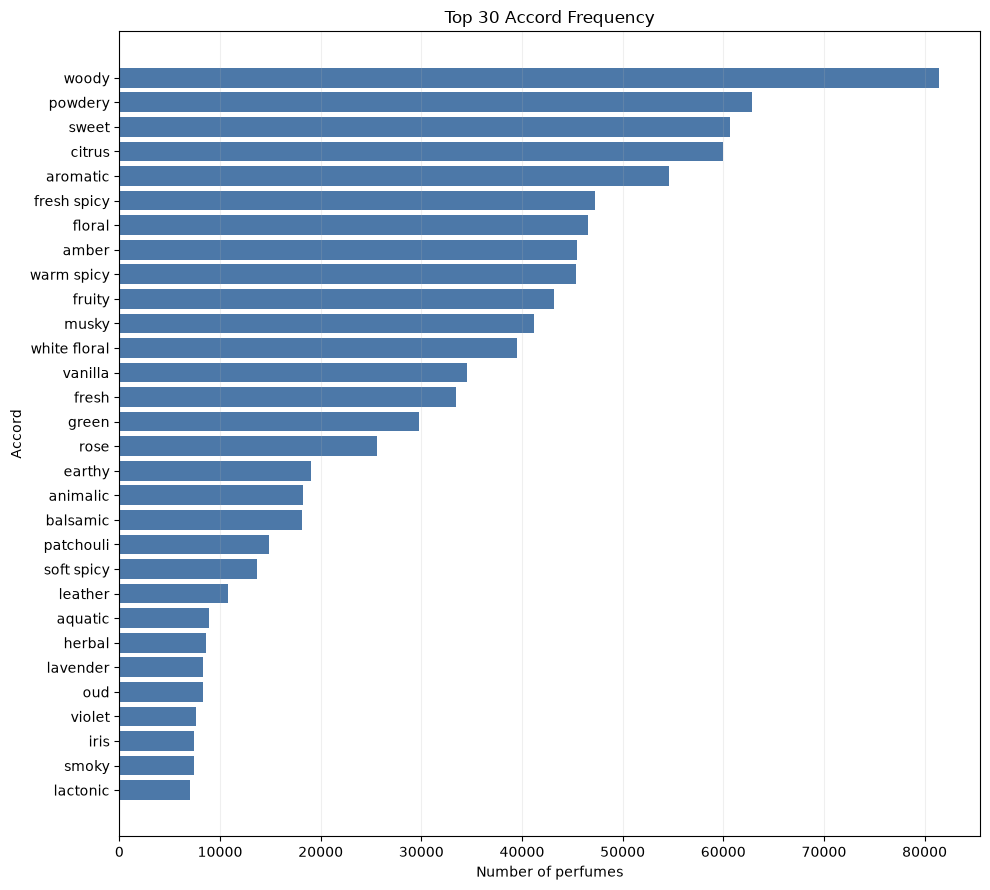

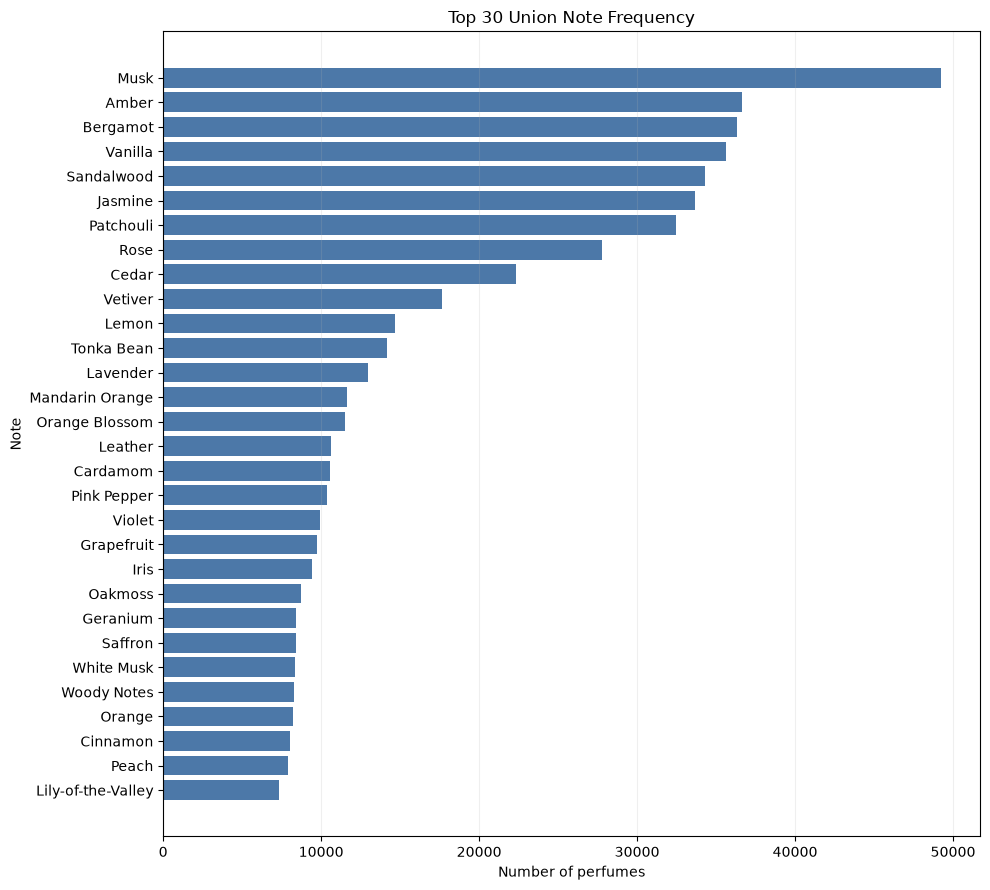

In [5]:
for frame, label, value_col, title in [
    (accord_dictionary_df, "accord", "perfume_count", "Top 30 Accord Frequency"),
    (note_dictionary_df, "note", "perfume_count", "Top 30 Union Note Frequency"),
]:
    plot_df = frame.head(30).sort_values(value_col)
    plt.figure(figsize=(10, 9))
    plt.barh(plot_df[label], plot_df[value_col], color="#4C78A8")
    plt.title(title)
    plt.xlabel("Number of perfumes")
    plt.ylabel(label.title())
    plt.grid(axis="x", alpha=0.2)
    plt.tight_layout()
    plt.show()


## 7. Note → Accord 관계

조건부확률 `P(Accord | Note)`(특정 Note가 있는 향수 중 해당 Accord도 있는 비율)과 Lift
(두 특징이 원래 기대보다 얼마나 자주 함께 등장하는지 나타내는 값)를 계산한다.

\[
P(A|N)=\frac{count(N\cap A)}{count(N)},\qquad
Lift(N,A)=\frac{count(N\cap A)\,N}{count(N)count(A)}
\]

`Note frequency >= 50`, `co-occurrence >= 20` 조건을 먼저 적용한다. co-occurrence(같은 향수 안에서 두 특징이 함께 등장한 횟수)와 threshold(분석에 포함할 최소 기준)를 함께 명시한다. 각 Note의 `P(A|N)` TOP 5와
Lift TOP 5의 합집합을 저장한다. 같은 관계가 두 목록에 모두 있으면 한 행으로 보존하고 두 rank를 기록한다.


In [6]:
note_accord_counts = collections.Counter()
for accord_ids, note_ids, _, _ in compact_records:
    for note_id in note_ids:
        for accord_id in accord_ids:
            note_accord_counts[(note_id, accord_id)] += 1

relation_rows = []
for (note_id, accord_id), cooccurrence_count in note_accord_counts.items():
    note_frequency = int(note_support[note_id])
    accord_frequency = int(accord_support[accord_id])
    relation_rows.append({
        "note": note_names[note_id],
        "accord": accord_names[accord_id],
        "note_frequency": note_frequency,
        "accord_frequency": accord_frequency,
        "cooccurrence_count": int(cooccurrence_count),
        "p_accord_given_note": cooccurrence_count / note_frequency,
        "p_note_given_accord": cooccurrence_count / accord_frequency,
        "lift": cooccurrence_count * total_perfumes / (
            note_frequency * accord_frequency
        ),
    })

note_accord_all_df = pd.DataFrame(relation_rows)
eligible_note_accord_df = note_accord_all_df[
    (note_accord_all_df["note_frequency"] >= 50)
    & (note_accord_all_df["cooccurrence_count"] >= 20)
].copy()

probability_ranked = eligible_note_accord_df.sort_values(
    ["note", "p_accord_given_note", "cooccurrence_count", "lift", "accord"],
    ascending=[True, False, False, False, True],
).copy()
probability_ranked["p_rank"] = (
    probability_ranked.groupby("note", sort=False).cumcount() + 1
)

lift_ranked = eligible_note_accord_df.sort_values(
    ["note", "lift", "cooccurrence_count", "p_accord_given_note", "accord"],
    ascending=[True, False, False, False, True],
).copy()
lift_ranked["lift_rank"] = (
    lift_ranked.groupby("note", sort=False).cumcount() + 1
)

probability_top = probability_ranked[probability_ranked["p_rank"] <= 5]
lift_top = lift_ranked[lift_ranked["lift_rank"] <= 5]

note_accord_bridge_df = (
    probability_top.merge(
        lift_top[["note", "accord", "lift_rank"]],
        on=["note", "accord"],
        how="outer",
    )
    .merge(
        eligible_note_accord_df,
        on=["note", "accord"],
        how="left",
        suffixes=("_rank_source", ""),
    )
)
# merge 과정의 중복 metric 열 대신 기준 metric 열만 남긴다.
drop_rank_source = [
    column for column in note_accord_bridge_df.columns
    if column.endswith("_rank_source")
]
note_accord_bridge_df = note_accord_bridge_df.drop(columns=drop_rank_source)
note_accord_bridge_df["selected_by"] = np.select(
    [
        note_accord_bridge_df["p_rank"].notna()
        & note_accord_bridge_df["lift_rank"].notna(),
        note_accord_bridge_df["p_rank"].notna(),
    ],
    ["P_AND_LIFT_TOP5", "P_TOP5"],
    default="LIFT_TOP5",
)
note_accord_bridge_df = note_accord_bridge_df[[
    "note", "accord", "note_frequency", "accord_frequency",
    "cooccurrence_count", "p_accord_given_note", "lift",
    "p_rank", "lift_rank", "selected_by",
]].sort_values(
    ["note", "p_rank", "lift_rank", "accord"],
    na_position="last",
).reset_index(drop=True)

note_accord_bridge_df.to_csv(
    output_dir / "10_note_accord_bridge.csv", index=False, encoding="utf-8-sig"
)

assert note_accord_all_df["p_accord_given_note"].between(0, 1).all()
assert (note_accord_all_df["cooccurrence_count"] <= note_accord_all_df[[
    "note_frequency", "accord_frequency"
]].min(axis=1)).all()

print(f"조건을 만족한 Note-Accord 관계 수: {len(eligible_note_accord_df):,}")
print(f"TOP 5 두 목록의 합집합 행 수: {len(note_accord_bridge_df):,}")
display(note_accord_bridge_df.head(30))


조건을 만족한 Note-Accord 관계 수: 20,432
TOP 5 두 목록의 합집합 행 수: 5,806


,note,accord,note_frequency,accord_frequency,cooccurrence_count,p_accord_given_note,lift,p_rank,lift_rank,selected_by
0,Absinthe,aromatic,236,54606,215,0.911017,2.201049,1.000000,NaN,P_TOP5
1,Absinthe,woody,236,81432,164,0.694915,1.125849,2.000000,NaN,P_TOP5
2,Absinthe,fresh spicy,236,47271,115,0.487288,1.359987,3.000000,NaN,P_TOP5
3,Absinthe,amber,236,45478,95,0.402542,1.167761,4.000000,NaN,P_TOP5
4,Absinthe,warm spicy,236,45319,94,0.398305,1.159522,5.000000,NaN,P_TOP5
5,Absinthe,bitter,236,1034,84,0.355932,45.414058,NaN,1.000000,LIFT_TOP5
6,Absinthe,anis,236,1418,20,0.084746,7.884703,NaN,2.000000,LIFT_TOP5
7,Absinthe,herbal,236,8607,39,0.165254,2.533054,NaN,3.000000,LIFT_TOP5
8,Absinthe,lavender,236,8336,37,0.156780,2.481279,NaN,4.000000,LIFT_TOP5
9,Absinthe,smoky,236,7407,32,0.135593,2.415123,NaN,5.000000,LIFT_TOP5


### 알려진 Note → Accord 예시 점검

아래 표는 Lemon→citrus, Cedar→woody, Vanilla→vanilla, Rose→rose가 실제 조건부확률과 Lift에서도
강한지 확인한다. 결과가 기대와 다르더라도 사람이 값을 수정하지 않는다.


In [7]:
expected_pairs = [
    ("Lemon", "citrus"),
    ("Cedar", "woody"),
    ("Vanilla", "vanilla"),
    ("Rose", "rose"),
]
expected_pair_rows = []
for note, accord in expected_pairs:
    match = note_accord_all_df[
        note_accord_all_df["note"].str.casefold().eq(note.casefold())
        & note_accord_all_df["accord"].str.casefold().eq(accord.casefold())
    ]
    if not match.empty:
        expected_pair_rows.append(match.iloc[0])
display(pd.DataFrame(expected_pair_rows).reset_index(drop=True))


,note,accord,note_frequency,accord_frequency,cooccurrence_count,p_accord_given_note,p_note_given_accord,lift
0,Lemon,citrus,14685,59969,12300,0.837589,0.205106,1.842671
1,Cedar,woody,22305,81432,19660,0.881417,0.241428,1.428005
2,Vanilla,vanilla,35628,34562,25290,0.709835,0.731728,2.709581
3,Rose,rose,27804,25617,17330,0.623292,0.676504,3.210011


## 8. Accord → Note 관계

반대 방향의 `P(Note | Accord)`(특정 Accord가 있는 향수에서 해당 Note가 등장하는 비율)을 계산한다.
희귀 Note의 우연한 대표 선정을 줄이기 위해 등장 향수 10개 이상인 주 분석 Note만 사용하고,
`P(Note | Accord)` 기준 TOP 10을 대표 Note로 정의한다. Lift와 전체 Note frequency를 함께 제공한다.


In [8]:
accord_note_candidates = note_accord_all_df[
    note_accord_all_df["note_frequency"] >= 10
].copy()
accord_note_bridge_df = accord_note_candidates.sort_values(
    ["accord", "p_note_given_accord", "cooccurrence_count", "lift", "note"],
    ascending=[True, False, False, False, True],
).copy()
accord_note_bridge_df["representative_rank"] = (
    accord_note_bridge_df.groupby("accord", sort=False).cumcount() + 1
)
accord_note_bridge_df = accord_note_bridge_df[
    accord_note_bridge_df["representative_rank"] <= 10
][[
    "accord", "note", "accord_frequency", "note_frequency",
    "cooccurrence_count", "p_note_given_accord", "lift", "representative_rank",
]].reset_index(drop=True)

accord_note_bridge_df.to_csv(
    output_dir / "10_accord_note_bridge.csv", index=False, encoding="utf-8-sig"
)

print(f"Accord별 대표 Note TOP 10 행 수: {len(accord_note_bridge_df):,}")
woody_example = accord_note_bridge_df[
    accord_note_bridge_df["accord"].str.casefold().eq("woody")
]
display(Markdown("### Woody Accord의 대표 Note"))
display(woody_example)


Accord별 대표 Note TOP 10 행 수: 912


### Woody Accord의 대표 Note

,accord,note,accord_frequency,note_frequency,cooccurrence_count,p_note_given_accord,lift,representative_rank
892,woody,Musk,81432,49244,31022,0.380956,1.020622,1
893,woody,Sandalwood,81432,34292,29401,0.361050,1.389050,2
894,woody,Patchouli,81432,32473,26573,0.326321,1.325765,3
895,woody,Bergamot,81432,36337,26164,0.321299,1.166550,4
896,woody,Amber,81432,36671,24304,0.298458,1.073751,5
897,woody,Jasmine,81432,33686,21633,0.265657,1.040437,6
898,woody,Vanilla,81432,35628,20970,0.257515,0.953576,7
899,woody,Cedar,81432,22305,19660,0.241428,1.428005,8
900,woody,Rose,81432,27804,17745,0.217912,1.033992,9
901,woody,Vetiver,81432,17674,15494,0.190269,1.420290,10


## 9. Accord → Season 관계

Season total이 20 이상인 향수만 사용한다. 각 향수에서 네 share의 합은 1이며, 코퍼스 baseline(비교 기준이 되는 전체 유효 향수의 평균)은 모든
유효 향수 share의 단순 평균이다. Season Lift(특정 Accord의 평균 계절 share가 코퍼스 평균의 몇 배인지
나타내는 값)는 `Accord mean share / corpus mean share`로 계산한다.

strongest / second / weakest Season은 코퍼스의 계절별 기본 비율 차이를 보정한 Lift 순서로 정한다.
`dominant_season_by_share`도 별도 제공해 원시 평균과 상대적 연관을 혼동하지 않게 한다.


In [9]:
season_share_matrix = np.asarray([
    season_share
    for _, _, season_share, _ in compact_records
    if season_share is not None
], dtype=np.float64)
corpus_season_baseline = season_share_matrix.mean(axis=0)

season_sums = np.zeros((len(accord_names), len(SEASONS)), dtype=np.float64)
season_support_by_accord = np.zeros(len(accord_names), dtype=np.int64)
for accord_ids, _, season_share, _ in compact_records:
    if season_share is None:
        continue
    share = np.asarray(season_share, dtype=np.float64)
    for accord_id in accord_ids:
        season_sums[accord_id] += share
        season_support_by_accord[accord_id] += 1

season_rows = []
for accord_id, accord in enumerate(accord_names):
    support = int(season_support_by_accord[accord_id])
    means = season_sums[accord_id] / support if support else np.full(4, np.nan)
    lifts = means / corpus_season_baseline if support else np.full(4, np.nan)
    if support:
        lift_order = np.argsort(-lifts, kind="stable")
        dominant_by_share = SEASONS[int(np.argmax(means))]
        strongest, second = SEASONS[lift_order[0]], SEASONS[lift_order[1]]
        weakest = SEASONS[lift_order[-1]]
    else:
        dominant_by_share = strongest = second = weakest = None

    row = {
        "accord": accord,
        "accord_frequency": int(accord_support[accord_id]),
        "eligible_perfume_count": support,
    }
    for index, season in enumerate(SEASONS):
        row[f"mean_{season}_share"] = means[index]
        row[f"corpus_{season}_share"] = corpus_season_baseline[index]
        row[f"{season}_lift"] = lifts[index]
    row.update({
        "dominant_season_by_share": dominant_by_share,
        "strongest_season_by_lift": strongest,
        "second_season_by_lift": second,
        "weakest_season_by_lift": weakest,
    })
    season_rows.append(row)

accord_season_bridge_df = (
    pd.DataFrame(season_rows)
    .sort_values(["accord_frequency", "accord"], ascending=[False, True])
    .reset_index(drop=True)
)
accord_season_bridge_df.to_csv(
    output_dir / "10_accord_season_bridge.csv", index=False, encoding="utf-8-sig"
)

valid_season_rows = accord_season_bridge_df[
    accord_season_bridge_df["eligible_perfume_count"] > 0
]
assert np.allclose(
    valid_season_rows[[f"mean_{name}_share" for name in SEASONS]].sum(axis=1),
    1.0,
)

display(pd.DataFrame({
    "season": SEASONS,
    "corpus_mean_share": corpus_season_baseline,
}))
display(accord_season_bridge_df.head(30))


,season,corpus_mean_share
0,winter,0.210156
1,spring,0.285781
2,summer,0.238738
3,autumn,0.265324


,accord,accord_frequency,eligible_perfume_count,mean_winter_share,corpus_winter_share,winter_lift,mean_spring_share,corpus_spring_share,spring_lift,mean_summer_share,corpus_summer_share,summer_lift,mean_autumn_share,corpus_autumn_share,autumn_lift,dominant_season_by_share,strongest_season_by_lift,second_season_by_lift,weakest_season_by_lift
0,woody,81432,37480,0.218648,0.210156,1.040405,0.278424,0.285781,0.974255,0.224375,0.238738,0.939835,0.278554,0.265324,1.049862,autumn,autumn,winter,summer
1,powdery,62885,28312,0.218960,0.210156,1.041890,0.283831,0.285781,0.993177,0.225454,0.238738,0.944356,0.271756,0.265324,1.024239,spring,winter,autumn,summer
2,sweet,60625,28279,0.221365,0.210156,1.053336,0.276641,0.285781,0.968016,0.234028,0.238738,0.980268,0.267967,0.265324,1.009958,spring,winter,autumn,spring
3,citrus,59969,26244,0.160199,0.210156,0.762284,0.317150,0.285781,1.109765,0.293858,0.238738,1.230879,0.228793,0.265324,0.862316,spring,summer,spring,winter
4,aromatic,54606,24714,0.189013,0.210156,0.899395,0.294852,0.285781,1.031743,0.258345,0.238738,1.082126,0.257789,0.265324,0.971599,spring,summer,spring,winter
5,fresh spicy,47271,21398,0.187318,0.210156,0.891326,0.296388,0.285781,1.037115,0.262120,0.238738,1.097938,0.254175,0.265324,0.957977,spring,summer,spring,winter
6,floral,46586,20332,0.173452,0.210156,0.825347,0.321491,0.285781,1.124955,0.272377,0.238738,1.140900,0.232681,0.265324,0.876967,spring,summer,spring,winter
7,amber,45478,19876,0.264559,0.210156,1.258871,0.246289,0.285781,0.861810,0.178828,0.238738,0.749053,0.310324,0.265324,1.169602,autumn,winter,autumn,summer
8,warm spicy,45319,20587,0.280214,0.210156,1.333359,0.234492,0.285781,0.820532,0.160750,0.238738,0.673331,0.324544,0.265324,1.223197,autumn,winter,autumn,summer
9,fruity,43222,20473,0.183072,0.210156,0.871124,0.305618,0.285781,1.069415,0.271839,0.238738,1.138646,0.239471,0.265324,0.902558,spring,summer,spring,winter


### 주요 Accord 20개의 Season profile heatmap

Heatmap(행과 열의 관계 강도를 색의 진하기로 보여주는 표)은 빈도 상위 20개 Accord의 평균 Season share를
표시한다. 색은 Lift가 아니라 향수별 share의 Accord 평균이다.


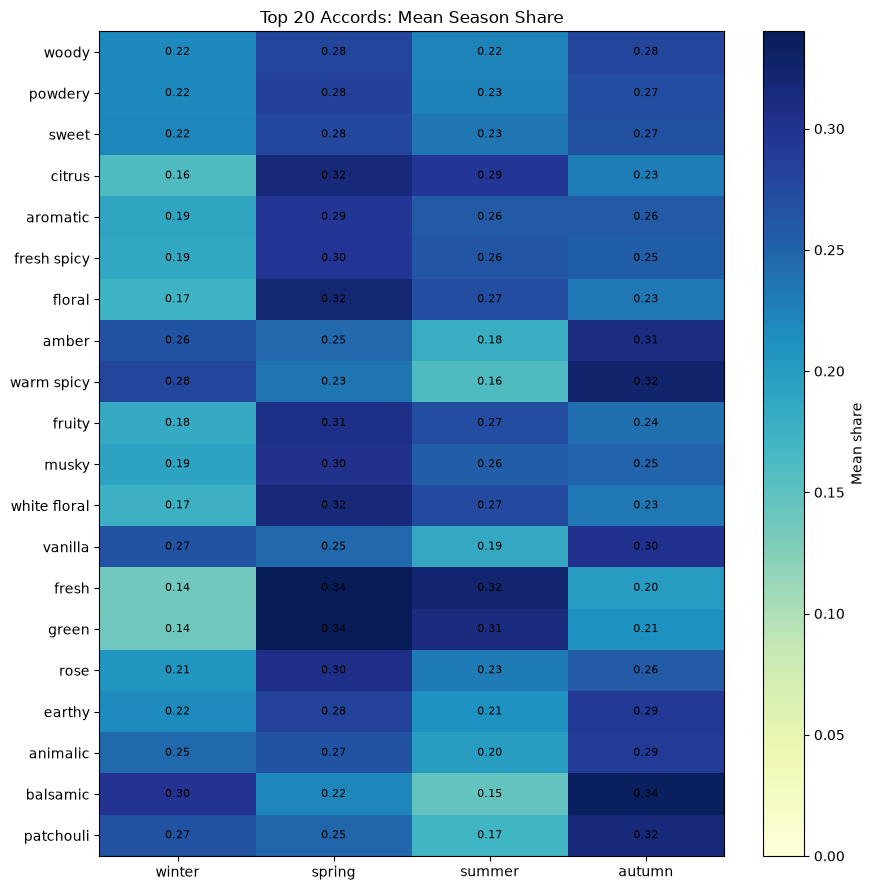

In [10]:
season_plot_df = accord_season_bridge_df[
    accord_season_bridge_df["eligible_perfume_count"] > 0
].head(20)
season_heat = season_plot_df[[f"mean_{name}_share" for name in SEASONS]].to_numpy()

fig, ax = plt.subplots(figsize=(9, 9))
image = ax.imshow(season_heat, aspect="auto", cmap="YlGnBu", vmin=0, vmax=season_heat.max())
ax.set_xticks(range(len(SEASONS)), SEASONS)
ax.set_yticks(range(len(season_plot_df)), season_plot_df["accord"])
ax.set_title("Top 20 Accords: Mean Season Share")
for row in range(season_heat.shape[0]):
    for column in range(season_heat.shape[1]):
        ax.text(column, row, f"{season_heat[row, column]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(image, ax=ax, label="Mean share")
plt.tight_layout()
plt.show()


## 10. Accord → Daypart 관계: 분포 진단

Daypart total이 20 이상인 향수만 사용한다. 먼저 각 Accord의 `mean_day_share - corpus_day_share` 분포를
모두 출력한다. 이 값이 양수면 코퍼스 평균보다 낮에, 음수면 밤에 상대적으로 더 연결된다.


Corpus Daypart baseline


,daypart,corpus_mean_share
0,day,0.620056
1,night,0.379944


Accord별 day difference 분포 요약


,day_difference_vs_corpus
count,91.000000
mean,-0.016600
std,0.106491
min,-0.253428
25%,-0.088493
50%,-0.007009
75%,0.052319
max,0.297758


Accord별 전체 day difference (오름차순)


,accord,accord_frequency,eligible_perfume_count,mean_day_share,mean_night_share,day_difference_vs_corpus
0,rubber,21,5,0.366629,0.633371,-0.253428
1,meat,4,2,0.369231,0.630769,-0.250826
2,whiskey,808,271,0.417645,0.582355,-0.202411
3,oud,8298,2554,0.422329,0.577671,-0.197728
4,alcohol,154,74,0.432914,0.567086,-0.187143
5,tobacco,4372,1506,0.438128,0.561872,-0.181929
6,sake,9,3,0.441491,0.558509,-0.178565
7,spice,8,2,0.452502,0.547498,-0.167554
8,coffee,1815,692,0.455571,0.544429,-0.164486
9,rum,1166,552,0.460776,0.539224,-0.159281


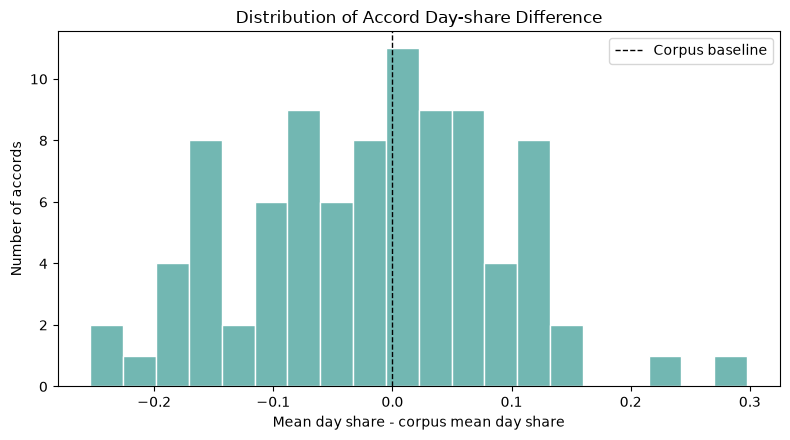

In [11]:
daypart_share_matrix = np.asarray([
    daypart_share
    for _, _, _, daypart_share in compact_records
    if daypart_share is not None
], dtype=np.float64)
corpus_daypart_baseline = daypart_share_matrix.mean(axis=0)

daypart_sums = np.zeros((len(accord_names), len(DAYPARTS)), dtype=np.float64)
daypart_support_by_accord = np.zeros(len(accord_names), dtype=np.int64)
for accord_ids, _, _, daypart_share in compact_records:
    if daypart_share is None:
        continue
    share = np.asarray(daypart_share, dtype=np.float64)
    for accord_id in accord_ids:
        daypart_sums[accord_id] += share
        daypart_support_by_accord[accord_id] += 1

daypart_rows = []
for accord_id, accord in enumerate(accord_names):
    support = int(daypart_support_by_accord[accord_id])
    means = daypart_sums[accord_id] / support if support else np.full(2, np.nan)
    daypart_rows.append({
        "accord": accord,
        "accord_frequency": int(accord_support[accord_id]),
        "eligible_perfume_count": support,
        "mean_day_share": means[0],
        "mean_night_share": means[1],
        "corpus_day_share": corpus_daypart_baseline[0],
        "corpus_night_share": corpus_daypart_baseline[1],
        "day_difference_vs_corpus": means[0] - corpus_daypart_baseline[0],
        "night_difference_vs_corpus": means[1] - corpus_daypart_baseline[1],
        "day_lift": means[0] / corpus_daypart_baseline[0],
        "night_lift": means[1] / corpus_daypart_baseline[1],
    })

accord_daypart_raw_df = pd.DataFrame(daypart_rows)
valid_daypart_raw_df = accord_daypart_raw_df[
    accord_daypart_raw_df["eligible_perfume_count"] > 0
].copy()

print("Corpus Daypart baseline")
display(pd.DataFrame({
    "daypart": DAYPARTS,
    "corpus_mean_share": corpus_daypart_baseline,
}))
print("Accord별 day difference 분포 요약")
display(valid_daypart_raw_df["day_difference_vs_corpus"].describe().to_frame())
print("Accord별 전체 day difference (오름차순)")
display(valid_daypart_raw_df[[
    "accord", "accord_frequency", "eligible_perfume_count",
    "mean_day_share", "mean_night_share", "day_difference_vs_corpus",
]].sort_values(["day_difference_vs_corpus", "accord"]).reset_index(drop=True))

plt.figure(figsize=(8, 4.5))
plt.hist(valid_daypart_raw_df["day_difference_vs_corpus"], bins=20, color="#72B7B2", edgecolor="white")
plt.axvline(0, color="black", linestyle="--", linewidth=1, label="Corpus baseline")
plt.title("Distribution of Accord Day-share Difference")
plt.xlabel("Mean day share - corpus mean day share")
plt.ylabel("Number of accords")
plt.legend()
plt.tight_layout()
plt.show()


### 데이터 기반 Day / Neutral / Night 기준

고정 숫자를 임의로 정하지 않고, 유효 Accord의 `day_difference_vs_corpus` 분포에서 Q25와 Q75를 계산한다.

- Q25 이하: `Night leaning`
- Q25 초과, Q75 미만: `Neutral`
- Q75 이상: `Day leaning`
- 유효 향수가 0개: `INSUFFICIENT_DATA` (근거 없이 세 그룹에 넣지 않음)

이는 의미의 절대 경계를 주장하는 규칙이 아니라, 현재 코퍼스 내부의 상대적 탐색 기준이다.


In [12]:
day_bias_q25 = float(valid_daypart_raw_df["day_difference_vs_corpus"].quantile(0.25))
day_bias_q75 = float(valid_daypart_raw_df["day_difference_vs_corpus"].quantile(0.75))

accord_daypart_bridge_df = accord_daypart_raw_df.copy()
accord_daypart_bridge_df["day_bias_q25"] = day_bias_q25
accord_daypart_bridge_df["day_bias_q75"] = day_bias_q75
accord_daypart_bridge_df["daypart_tendency"] = np.select(
    [
        accord_daypart_bridge_df["eligible_perfume_count"].eq(0),
        accord_daypart_bridge_df["day_difference_vs_corpus"].le(day_bias_q25),
        accord_daypart_bridge_df["day_difference_vs_corpus"].ge(day_bias_q75),
    ],
    ["INSUFFICIENT_DATA", "Night leaning", "Day leaning"],
    default="Neutral",
)
accord_daypart_bridge_df = accord_daypart_bridge_df.sort_values(
    ["accord_frequency", "accord"], ascending=[False, True]
).reset_index(drop=True)
accord_daypart_bridge_df.to_csv(
    output_dir / "10_accord_daypart_bridge.csv", index=False, encoding="utf-8-sig"
)

valid_daypart_rows = accord_daypart_bridge_df[
    accord_daypart_bridge_df["eligible_perfume_count"] > 0
]
assert np.allclose(
    valid_daypart_rows[["mean_day_share", "mean_night_share"]].sum(axis=1),
    1.0,
)

print(f"Q25={day_bias_q25:.6f}, Q75={day_bias_q75:.6f}")
display(accord_daypart_bridge_df["daypart_tendency"].value_counts(dropna=False).to_frame("accord_count"))
display(accord_daypart_bridge_df.head(30))


Q25=-0.088493, Q75=0.052319


,accord_count
daypart_tendency,
Neutral,45
Day leaning,23
Night leaning,23
INSUFFICIENT_DATA,1


,accord,accord_frequency,eligible_perfume_count,mean_day_share,mean_night_share,corpus_day_share,corpus_night_share,day_difference_vs_corpus,night_difference_vs_corpus,day_lift,night_lift,day_bias_q25,day_bias_q75,daypart_tendency
0,woody,81432,29341,0.601017,0.398983,0.620056,0.379944,-0.019040,0.019040,0.969294,1.050112,-0.088493,0.052319,Neutral
1,powdery,62885,21977,0.617794,0.382206,0.620056,0.379944,-0.002262,0.002262,0.996352,1.005954,-0.088493,0.052319,Neutral
2,sweet,60625,22063,0.616269,0.383731,0.620056,0.379944,-0.003788,0.003788,0.993892,1.009969,-0.088493,0.052319,Neutral
3,citrus,59969,20521,0.680374,0.319626,0.620056,0.379944,0.060317,-0.060317,1.097277,0.841247,-0.088493,0.052319,Day leaning
4,aromatic,54606,19216,0.632975,0.367025,0.620056,0.379944,0.012918,-0.012918,1.020834,0.966000,-0.088493,0.052319,Neutral
5,fresh spicy,47271,16523,0.637023,0.362977,0.620056,0.379944,0.016967,-0.016967,1.027364,0.955343,-0.088493,0.052319,Neutral
6,floral,46586,15740,0.680225,0.319775,0.620056,0.379944,0.060169,-0.060169,1.097038,0.841637,-0.088493,0.052319,Day leaning
7,amber,45478,15316,0.534930,0.465070,0.620056,0.379944,-0.085127,0.085127,0.862712,1.224051,-0.088493,0.052319,Neutral
8,warm spicy,45319,16074,0.520300,0.479700,0.620056,0.379944,-0.099756,0.099756,0.839117,1.262556,-0.088493,0.052319,Night leaning
9,fruity,43222,16047,0.661292,0.338708,0.620056,0.379944,0.041236,-0.041236,1.066503,0.891469,-0.088493,0.052319,Neutral


### 주요 Accord 20개의 Day/Night profile

빈도 상위 20개 Accord의 평균 day/night share를 코퍼스 baseline과 함께 비교한다.


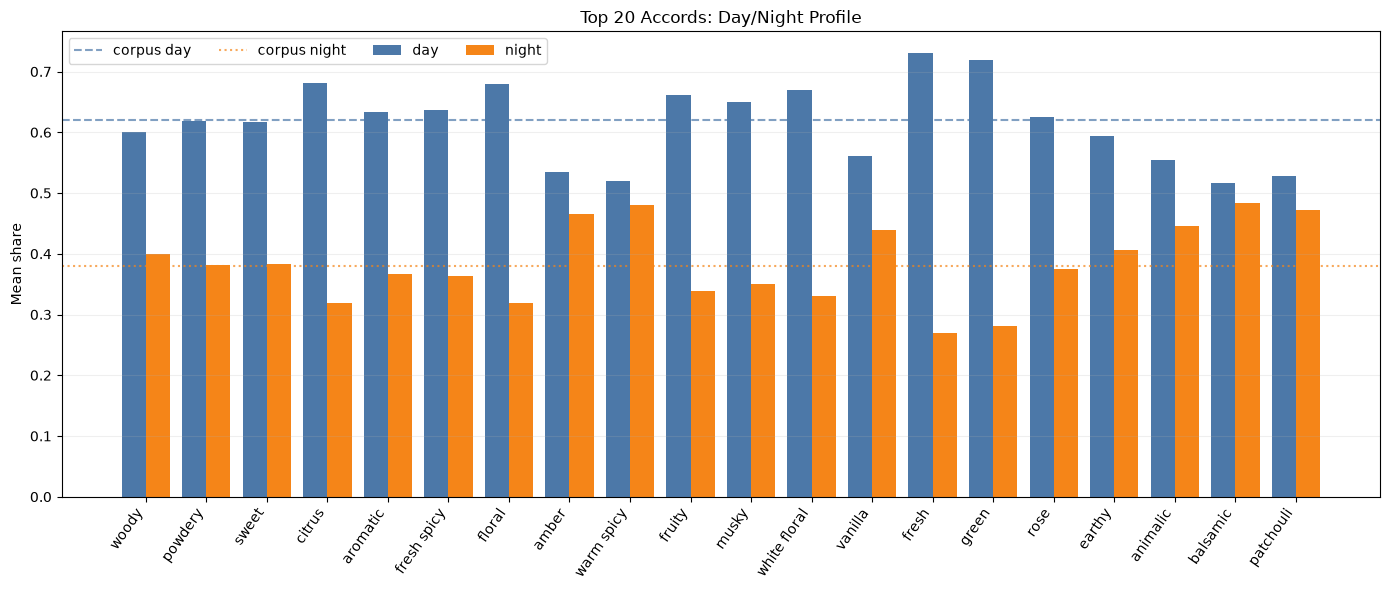

In [13]:
daypart_plot_df = accord_daypart_bridge_df[
    accord_daypart_bridge_df["eligible_perfume_count"] > 0
].head(20)
positions = np.arange(len(daypart_plot_df))
width = 0.4

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(positions - width / 2, daypart_plot_df["mean_day_share"], width, label="day", color="#4C78A8")
ax.bar(positions + width / 2, daypart_plot_df["mean_night_share"], width, label="night", color="#F58518")
ax.axhline(corpus_daypart_baseline[0], color="#4C78A8", linestyle="--", alpha=0.7, label="corpus day")
ax.axhline(corpus_daypart_baseline[1], color="#F58518", linestyle=":", alpha=0.7, label="corpus night")
ax.set_xticks(positions, daypart_plot_df["accord"], rotation=55, ha="right")
ax.set_ylabel("Mean share")
ax.set_title("Top 20 Accords: Day/Night Profile")
ax.legend(ncol=4)
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()


## 11. Accord Context Profile

앞의 결과를 결합해 각 Accord가 대표 Note, 계절, 시간대와 어떻게 연결되는지 한 행에서 확인한다.
CSV의 목록은 JSON 문자열과 펼친 열을 함께 제공한다.


In [14]:
representative_note_map = (
    accord_note_bridge_df.sort_values(["accord", "representative_rank"])
    .groupby("accord")["note"]
    .apply(list)
    .to_dict()
)
accord_dictionary_lookup = accord_dictionary_df.set_index("accord")
season_lookup = accord_season_bridge_df.set_index("accord")
daypart_lookup = accord_daypart_bridge_df.set_index("accord")

context_rows = []
for accord in accord_dictionary_df["accord"]:
    dictionary_row = accord_dictionary_lookup.loc[accord]
    season_row = season_lookup.loc[accord]
    daypart_row = daypart_lookup.loc[accord]
    representative_notes = representative_note_map.get(accord, [])[:5]
    padded_notes = representative_notes + [None] * (5 - len(representative_notes))
    season_profile = {
        season: float(season_row[f"mean_{season}_share"])
        if pd.notna(season_row[f"mean_{season}_share"])
        else None
        for season in SEASONS
    }

    row = {
        "accord": accord,
        "frequency": int(dictionary_row["perfume_count"]),
        "mean_strength": dictionary_row["mean_strength"],
        "representative_notes": json.dumps(representative_notes, ensure_ascii=False),
        "season_profile": json.dumps(season_profile, ensure_ascii=False),
        "dominant_season": season_row["strongest_season_by_lift"],
        "dominant_season_by_share": season_row["dominant_season_by_share"],
        "season_eligible_perfume_count": int(season_row["eligible_perfume_count"]),
        "day_share": daypart_row["mean_day_share"],
        "night_share": daypart_row["mean_night_share"],
        "daypart_eligible_perfume_count": int(daypart_row["eligible_perfume_count"]),
        "daypart_tendency": daypart_row["daypart_tendency"],
    }
    for index, note in enumerate(padded_notes, start=1):
        row[f"representative_note_{index}"] = note
    for season in SEASONS:
        row[f"{season}_share"] = season_row[f"mean_{season}_share"]
        row[f"{season}_lift"] = season_row[f"{season}_lift"]
    context_rows.append(row)

accord_context_profile_df = pd.DataFrame(context_rows)
accord_context_profile_df.to_csv(
    output_dir / "10_accord_context_profile.csv", index=False, encoding="utf-8-sig"
)
display(accord_context_profile_df.head(30))


,accord,frequency,mean_strength,representative_notes,season_profile,dominant_season,dominant_season_by_share,season_eligible_perfume_count,day_share,night_share,daypart_eligible_perfume_count,daypart_tendency,representative_note_1,representative_note_2,representative_note_3,representative_note_4,representative_note_5,winter_share,winter_lift,spring_share,spring_lift,summer_share,summer_lift,autumn_share,autumn_lift
0,woody,81432,65.828360,"[""Musk"", ""Sandalwood"", ""Patchouli"", ""Bergamot""...","{""winter"": 0.21864752473550414, ""spring"": 0.27...",autumn,autumn,37480,0.601017,0.398983,29341,Neutral,Musk,Sandalwood,Patchouli,Bergamot,Amber,0.218648,1.040405,0.278424,0.974255,0.224375,0.939835,0.278554,1.049862
1,powdery,62885,48.343150,"[""Musk"", ""Sandalwood"", ""Vanilla"", ""Amber"", ""Be...","{""winter"": 0.21895956910746753, ""spring"": 0.28...",winter,spring,28312,0.617794,0.382206,21977,Neutral,Musk,Sandalwood,Vanilla,Amber,Bergamot,0.218960,1.041890,0.283831,0.993177,0.225454,0.944356,0.271756,1.024239
2,sweet,60625,54.332833,"[""Musk"", ""Vanilla"", ""Jasmine"", ""Amber"", ""Sanda...","{""winter"": 0.22136511916918142, ""spring"": 0.27...",winter,spring,28279,0.616269,0.383731,22063,Neutral,Musk,Vanilla,Jasmine,Amber,Sandalwood,0.221365,1.053336,0.276641,0.968016,0.234028,0.980268,0.267967,1.009958
3,citrus,59969,67.283046,"[""Bergamot"", ""Musk"", ""Jasmine"", ""Amber"", ""Sand...","{""winter"": 0.16019866011539244, ""spring"": 0.31...",summer,spring,26244,0.680374,0.319626,20521,Day leaning,Bergamot,Musk,Jasmine,Amber,Sandalwood,0.160199,0.762284,0.317150,1.109765,0.293858,1.230879,0.228793,0.862316
4,aromatic,54606,56.065597,"[""Bergamot"", ""Musk"", ""Amber"", ""Sandalwood"", ""P...","{""winter"": 0.18901341077541678, ""spring"": 0.29...",summer,spring,24714,0.632975,0.367025,19216,Neutral,Bergamot,Musk,Amber,Sandalwood,Patchouli,0.189013,0.899395,0.294852,1.031743,0.258345,1.082126,0.257789,0.971599
5,fresh spicy,47271,51.155867,"[""Bergamot"", ""Musk"", ""Amber"", ""Patchouli"", ""Sa...","{""winter"": 0.18731769183870656, ""spring"": 0.29...",summer,spring,21398,0.637023,0.362977,16523,Neutral,Bergamot,Musk,Amber,Patchouli,Sandalwood,0.187318,0.891326,0.296388,1.037115,0.262120,1.097938,0.254175,0.957977
6,floral,46586,56.229189,"[""Musk"", ""Jasmine"", ""Rose"", ""Bergamot"", ""Amber""]","{""winter"": 0.17345172817065915, ""spring"": 0.32...",summer,spring,20332,0.680225,0.319775,15740,Day leaning,Musk,Jasmine,Rose,Bergamot,Amber,0.173452,0.825347,0.321491,1.124955,0.272377,1.140900,0.232681,0.876967
7,amber,45478,61.021549,"[""Amber"", ""Musk"", ""Vanilla"", ""Patchouli"", ""Ber...","{""winter"": 0.2645594786204693, ""spring"": 0.246...",winter,autumn,19876,0.534930,0.465070,15316,Neutral,Amber,Musk,Vanilla,Patchouli,Bergamot,0.264559,1.258871,0.246289,0.861810,0.178828,0.749053,0.310324,1.169602
8,warm spicy,45319,57.098281,"[""Patchouli"", ""Sandalwood"", ""Amber"", ""Musk"", ""...","{""winter"": 0.28021377302038486, ""spring"": 0.23...",winter,autumn,20587,0.520300,0.479700,16074,Night leaning,Patchouli,Sandalwood,Amber,Musk,Vanilla,0.280214,1.333359,0.234492,0.820532,0.160750,0.673331,0.324544,1.223197
9,fruity,43222,64.469044,"[""Musk"", ""Vanilla"", ""Jasmine"", ""Amber"", ""Sanda...","{""winter"": 0.18307217298352654, ""spring"": 0.30...",summer,spring,20473,0.661292,0.338708,16047,Neutral,Musk,Vanilla,Jasmine,Amber,Sandalwood,0.183072,0.871124,0.305618,1.069415,0.271839,1.138646,0.239471,0.902558


## 12. Accord ↔ Accord 관계

Jaccard Similarity(두 항목이 함께 등장하는 정도를 전체 등장 범위와 비교하는 유사도)는 교집합 크기를
합집합 크기로 나눈 값이다. Lift도 함께 계산해 흔한 Accord끼리라는 이유만으로 높은 동시 등장 수가 나온
경우를 구분한다.

\[
Jaccard(A,B)=\frac{|A\cap B|}{|A\cup B|}
\]

co-occurrence 100 이상인 pair만 남기고, 각 Accord에서 Jaccard 우선 TOP 10을 표시한다. CSV는 조건을
만족한 모든 관계를 양방향 행으로 저장하며 `jaccard_rank`와 `is_top10`을 제공한다.


In [15]:
accord_pair_counts = collections.Counter()
for accord_ids, _, _, _ in compact_records:
    for accord_a_id, accord_b_id in itertools.combinations(accord_ids, 2):
        accord_pair_counts[(accord_a_id, accord_b_id)] += 1

unique_pair_rows = []
for (accord_a_id, accord_b_id), cooccurrence_count in accord_pair_counts.items():
    if cooccurrence_count < 100:
        continue
    frequency_a = int(accord_support[accord_a_id])
    frequency_b = int(accord_support[accord_b_id])
    union_count = frequency_a + frequency_b - cooccurrence_count
    unique_pair_rows.append({
        "accord_a": accord_names[accord_a_id],
        "accord_b": accord_names[accord_b_id],
        "frequency_a": frequency_a,
        "frequency_b": frequency_b,
        "cooccurrence_count": int(cooccurrence_count),
        "union_count": int(union_count),
        "jaccard_similarity": cooccurrence_count / union_count,
        "lift": cooccurrence_count * total_perfumes / (frequency_a * frequency_b),
    })
accord_pair_unique_df = pd.DataFrame(unique_pair_rows)

directional_rows = []
for row in accord_pair_unique_df.itertuples(index=False):
    directional_rows.extend([
        {
            "accord": row.accord_a,
            "related_accord": row.accord_b,
            "accord_frequency": row.frequency_a,
            "related_accord_frequency": row.frequency_b,
            "cooccurrence_count": row.cooccurrence_count,
            "union_count": row.union_count,
            "jaccard_similarity": row.jaccard_similarity,
            "lift": row.lift,
        },
        {
            "accord": row.accord_b,
            "related_accord": row.accord_a,
            "accord_frequency": row.frequency_b,
            "related_accord_frequency": row.frequency_a,
            "cooccurrence_count": row.cooccurrence_count,
            "union_count": row.union_count,
            "jaccard_similarity": row.jaccard_similarity,
            "lift": row.lift,
        },
    ])

accord_cooccurrence_df = pd.DataFrame(directional_rows).sort_values(
    ["accord", "jaccard_similarity", "cooccurrence_count", "lift", "related_accord"],
    ascending=[True, False, False, False, True],
).reset_index(drop=True)
accord_cooccurrence_df["jaccard_rank"] = (
    accord_cooccurrence_df.groupby("accord", sort=False).cumcount() + 1
)
accord_cooccurrence_df["is_top10"] = accord_cooccurrence_df["jaccard_rank"] <= 10
accord_cooccurrence_df.to_csv(
    output_dir / "10_accord_cooccurrence.csv", index=False, encoding="utf-8-sig"
)
accord_related_top10_df = accord_cooccurrence_df[
    accord_cooccurrence_df["is_top10"]
].copy()

assert accord_cooccurrence_df["jaccard_similarity"].between(0, 1).all()
print(f"co-occurrence >= 100인 고유 Accord pair 수: {len(accord_pair_unique_df):,}")
print(f"Accord별 Jaccard TOP 10 방향성 행 수: {len(accord_related_top10_df):,}")
display(Markdown("### citrus의 연관 Accord TOP 10"))
display(accord_related_top10_df[
    accord_related_top10_df["accord"].str.casefold().eq("citrus")
])


co-occurrence >= 100인 고유 Accord pair 수: 1,247
Accord별 Jaccard TOP 10 방향성 행 수: 642


### citrus의 연관 Accord TOP 10

,accord,related_accord,accord_frequency,related_accord_frequency,cooccurrence_count,union_count,jaccard_similarity,lift,jaccard_rank,is_top10
579,citrus,fresh spicy,59969,47271,29822,77418,0.385208,1.387902,1,True
580,citrus,aromatic,59969,54606,31607,82968,0.380954,1.273385,2,True
581,citrus,woody,59969,81432,38224,103177,0.370470,1.032661,3,True
582,citrus,white floral,59969,39497,22725,76741,0.296126,1.265775,4,True
583,citrus,powdery,59969,62885,26439,96415,0.274221,0.924942,5,True
584,citrus,floral,59969,46586,22125,84430,0.262051,1.044828,6,True
585,citrus,sweet,59969,60625,24700,95894,0.257576,0.896318,7,True
586,citrus,fresh,59969,33478,18826,74621,0.252288,1.237130,8,True
587,citrus,musky,59969,41154,19037,82086,0.231915,1.017661,9,True
588,citrus,fruity,59969,43222,19255,83936,0.229401,0.980066,10,True


### 상위 Accord co-occurrence heatmap

빈도 상위 15개 Accord 사이의 Jaccard Similarity를 표시한다. 대각선은 자기 자신이므로 1로 둔다.


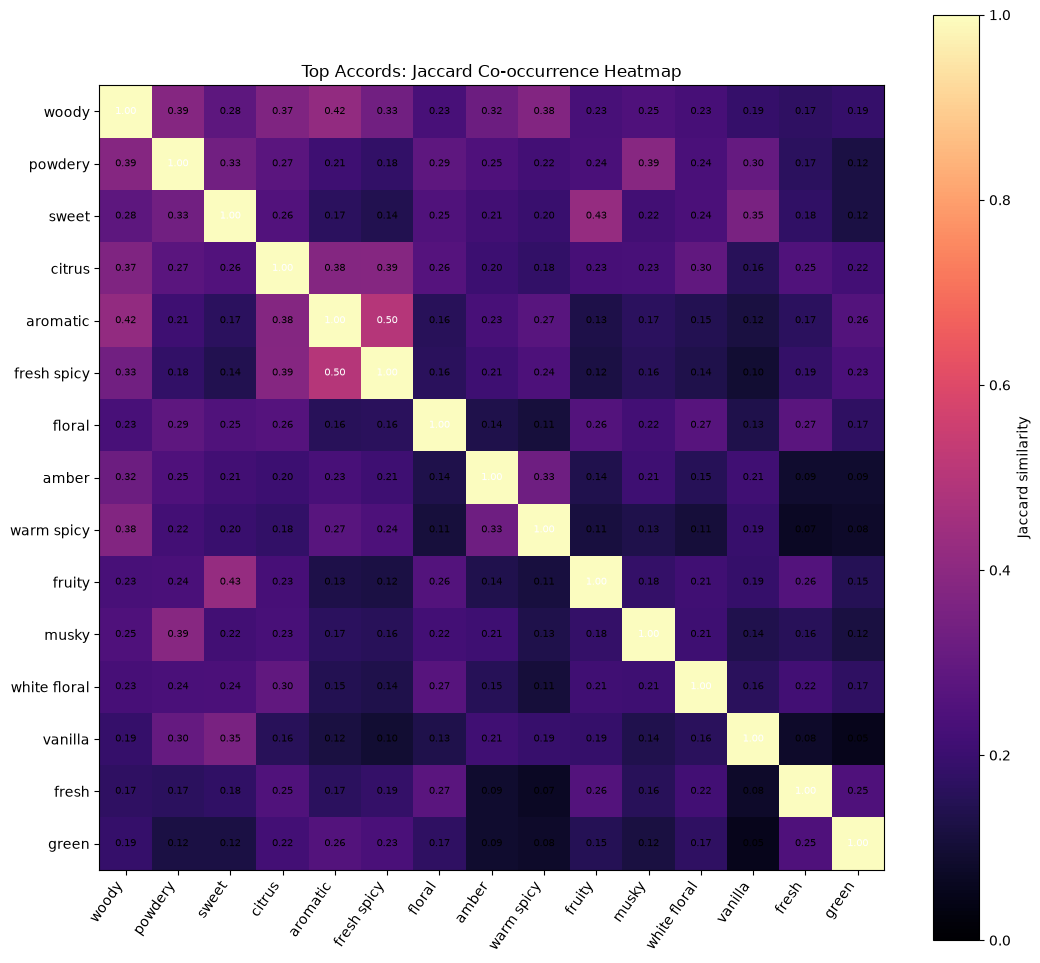

In [16]:
heatmap_accords = accord_dictionary_df.head(15)["accord"].tolist()
heatmap_index = {accord: index for index, accord in enumerate(heatmap_accords)}
jaccard_heat = np.eye(len(heatmap_accords), dtype=np.float64)
for row in accord_pair_unique_df.itertuples(index=False):
    if row.accord_a in heatmap_index and row.accord_b in heatmap_index:
        a = heatmap_index[row.accord_a]
        b = heatmap_index[row.accord_b]
        jaccard_heat[a, b] = row.jaccard_similarity
        jaccard_heat[b, a] = row.jaccard_similarity

fig, ax = plt.subplots(figsize=(11, 10))
image = ax.imshow(jaccard_heat, cmap="magma", vmin=0, vmax=1)
ax.set_xticks(range(len(heatmap_accords)), heatmap_accords, rotation=55, ha="right")
ax.set_yticks(range(len(heatmap_accords)), heatmap_accords)
ax.set_title("Top Accords: Jaccard Co-occurrence Heatmap")
for row in range(len(heatmap_accords)):
    for column in range(len(heatmap_accords)):
        ax.text(column, row, f"{jaccard_heat[row, column]:.2f}", ha="center", va="center", fontsize=7,
                color="white" if jaccard_heat[row, column] > 0.45 else "black")
fig.colorbar(image, ax=ax, label="Jaccard similarity")
plt.tight_layout()
plt.show()


## 13. 자연어 Query 유형과 데이터 표현 가능성

Mapping(한 표현을 데이터의 다른 Feature와 연결하는 규칙)의 가능 범위는 데이터 분석 결과와 서비스
설계를 분리해 판단한다. canonical label(데이터에 저장된 기준 이름)과 community-vote(사용자 집단이 계절·시간대에 투표한 값)의 의미도 구분한다.

| Query 유형 | 예시 | 직접 표현 가능 | 부분적으로 가능 | 현재 데이터만으로 불가능한 부분 |
|---|---|---|---|---|
| Direct Scent | 시트러스 향, 우디한 향, 바닐라 향, 장미 향 | canonical Accord / Note 이름 | 형태소·동의어 정규화 | 데이터에 없는 동의어 의미 판정 |
| Context | 여름 향, 겨울밤 향, 낮에 쓰기 좋은 향 | Season / Daypart | Accord와 context의 community-vote 연관 | 감성적 맥락의 의미 해석 |
| Sensory / Descriptive | 상큼한, 포근한, 차가운, 촉촉한, 깨끗한 | 직접 Feature 없음 | 향후 라벨이 있으면 일부 Accord 검증 가능 | 현재 데이터만으로 형용사→Feature 증명 |
| Scene / Abstract | 비 오는 숲, 휴양지, 호텔 로비, 흰 셔츠 | 직접 Feature 없음 | 장면에 명시된 계절·시간 단어만 분리 가능 | 장면 전체의 Accord / Note 의미 해석 |

Direct Scent와 Context의 명시적 단어는 Level A로 처리할 수 있다. Sensory와 Scene 표현은 현재 데이터에
해당 자연어 라벨이 없으므로 구체 Accord 후보를 사람이 임의로 넣지 않는다.


## 14. 데이터만으로 구성한 Query 예시

Template(일정한 구조를 가진 반복 가능한 입력 형식)은 다음과 같다.

- `{Accord} 향`
- `{Accord1}와 {Accord2}가 함께 느껴지는 향`
- `{Season}에 어울리는 {Accord} 향`
- `{Season} {Daypart}에 어울리는 {Accord} 향`
- `{Note} 노트가 느껴지는 향`

아래 예시는 실제 데이터의 Feature 이름과 분석된 관계만 넣어 결정적으로 생성한다. 자연스러운 문장 예시일
뿐이며 Golden Set이나 정답 label이 아니다.


In [17]:
season_ko = {"winter": "겨울", "spring": "봄", "summer": "여름", "autumn": "가을"}
daypart_ko = {"day": "낮", "night": "밤"}
query_example_rows = []

def add_query(template, query, source_features):
    if query not in {row["query"] for row in query_example_rows}:
        query_example_rows.append({
            "template": template,
            "query": query,
            "source_features": source_features,
            "golden_set": False,
        })

for accord in accord_dictionary_df.head(10)["accord"]:
    add_query("{Accord} 향", f"{accord} 향", f"ACCORD:{accord}")

for note in note_dictionary_df.head(10)["note"]:
    add_query("{Note} 노트가 느껴지는 향", f"{note} 노트가 느껴지는 향", f"NOTE:{note}")

seen_pairs = set()
for row in accord_related_top10_df.sort_values(
    ["jaccard_similarity", "cooccurrence_count"], ascending=False
).itertuples(index=False):
    pair_key = tuple(sorted((row.accord, row.related_accord)))
    if pair_key in seen_pairs:
        continue
    seen_pairs.add(pair_key)
    add_query(
        "{Accord1}와 {Accord2}가 함께 느껴지는 향",
        f"{row.accord}와 {row.related_accord}가 함께 느껴지는 향",
        f"ACCORD:{row.accord}|ACCORD:{row.related_accord}",
    )
    if len(seen_pairs) >= 8:
        break

for row in accord_season_bridge_df.head(8).itertuples(index=False):
    season = row.strongest_season_by_lift
    if season:
        add_query(
            "{Season}에 어울리는 {Accord} 향",
            f"{season_ko[season]}에 어울리는 {row.accord} 향",
            f"SEASON:{season}|ACCORD:{row.accord}",
        )

contextual_rows = accord_daypart_bridge_df[
    accord_daypart_bridge_df["daypart_tendency"].isin(["Day leaning", "Night leaning"])
].head(8)
season_by_accord = accord_season_bridge_df.set_index("accord")["strongest_season_by_lift"].to_dict()
for row in contextual_rows.itertuples(index=False):
    season = season_by_accord.get(row.accord)
    daypart = "day" if row.daypart_tendency == "Day leaning" else "night"
    if season:
        add_query(
            "{Season} {Daypart}에 어울리는 {Accord} 향",
            f"{season_ko[season]} {daypart_ko[daypart]}에 어울리는 {row.accord} 향",
            f"SEASON:{season}|DAYPART:{daypart}|ACCORD:{row.accord}",
        )

query_examples_df = pd.DataFrame(query_example_rows)
query_examples_df.to_csv(
    output_dir / "10_query_examples.csv", index=False, encoding="utf-8-sig"
)
assert len(query_examples_df) >= 30
print(f"생성한 비-Golden Query 예시 수: {len(query_examples_df):,}")
display(query_examples_df)


생성한 비-Golden Query 예시 수: 44


,template,query,source_features,golden_set
0,{Accord} 향,woody 향,ACCORD:woody,False
1,{Accord} 향,powdery 향,ACCORD:powdery,False
2,{Accord} 향,sweet 향,ACCORD:sweet,False
3,{Accord} 향,citrus 향,ACCORD:citrus,False
4,{Accord} 향,aromatic 향,ACCORD:aromatic,False
5,{Accord} 향,fresh spicy 향,ACCORD:fresh spicy,False
6,{Accord} 향,floral 향,ACCORD:floral,False
7,{Accord} 향,amber 향,ACCORD:amber,False
8,{Accord} 향,warm spicy 향,ACCORD:warm spicy,False
9,{Accord} 향,fruity 향,ACCORD:fruity,False


## 15. 직접 매핑하면 안 되는 표현

아래 표현은 원본 데이터에 자연어 의미 label이 없으므로 특정 Accord / Note를 후보라고 쓰는 것조차 데이터
근거가 아니다. `possible_related_features`는 향후 검증 대상 Feature **유형**만 기록하고, 구체 Feature는
비워 둔다.


In [18]:
unsupported_expressions = [
    ("포근한", "ACCORD / NOTE (외부 라벨 후 검증)"),
    ("촉촉한", "ACCORD / NOTE (외부 라벨 후 검증)"),
    ("차가운", "ACCORD / NOTE (외부 라벨 후 검증)"),
    ("깨끗한", "ACCORD / NOTE (외부 라벨 후 검증)"),
    ("고급스러운", "ACCORD / NOTE (외부 라벨 후 검증)"),
    ("섹시한", "ACCORD / NOTE (외부 라벨 후 검증)"),
    ("도시적인", "ACCORD / NOTE (외부 라벨 후 검증)"),
    ("자연스러운", "ACCORD / NOTE (외부 라벨 후 검증)"),
    ("비 오는 숲", "ACCORD / NOTE / CONTEXT (외부 라벨 후 검증)"),
    ("휴양지", "ACCORD / NOTE / CONTEXT (외부 라벨 후 검증)"),
    ("호텔", "ACCORD / NOTE / CONTEXT (외부 라벨 후 검증)"),
    ("빨래", "ACCORD / NOTE (외부 라벨 후 검증)"),
    ("이불", "ACCORD / NOTE / CONTEXT (외부 라벨 후 검증)"),
]
external_mapping_df = pd.DataFrame(
    unsupported_expressions,
    columns=["expression", "possible_related_features"],
)
external_mapping_df["evidence_status"] = "EXTERNAL_MAPPING_REQUIRED"
external_mapping_df.to_csv(
    output_dir / "10_external_mapping_inventory.csv", index=False, encoding="utf-8-sig"
)
display(external_mapping_df)


,expression,possible_related_features,evidence_status
0,포근한,ACCORD / NOTE (외부 라벨 후 검증),EXTERNAL_MAPPING_REQUIRED
1,촉촉한,ACCORD / NOTE (외부 라벨 후 검증),EXTERNAL_MAPPING_REQUIRED
2,차가운,ACCORD / NOTE (외부 라벨 후 검증),EXTERNAL_MAPPING_REQUIRED
3,깨끗한,ACCORD / NOTE (외부 라벨 후 검증),EXTERNAL_MAPPING_REQUIRED
4,고급스러운,ACCORD / NOTE (외부 라벨 후 검증),EXTERNAL_MAPPING_REQUIRED
5,섹시한,ACCORD / NOTE (외부 라벨 후 검증),EXTERNAL_MAPPING_REQUIRED
6,도시적인,ACCORD / NOTE (외부 라벨 후 검증),EXTERNAL_MAPPING_REQUIRED
7,자연스러운,ACCORD / NOTE (외부 라벨 후 검증),EXTERNAL_MAPPING_REQUIRED
8,비 오는 숲,ACCORD / NOTE / CONTEXT (외부 라벨 후 검증),EXTERNAL_MAPPING_REQUIRED
9,휴양지,ACCORD / NOTE / CONTEXT (외부 라벨 후 검증),EXTERNAL_MAPPING_REQUIRED


## 16. Evidence Level 정의

| Level | 이름 | 판정 기준 | 예시 |
|---|---|---|---|
| A | Direct | canonical 문자열 또는 명시적 context 단어가 Feature와 직접 대응 | `citrus` → citrus Accord, `vanilla` → Vanilla Note |
| B | Data Association | 조건부확률·Lift·Jaccard와 support로 데이터 동시 등장 관계가 확인됨 | Lemon Note → citrus Accord |
| C | Context Association | Season / Daypart community-vote share를 코퍼스 baseline과 비교 가능 | citrus Accord → summer context |
| D | External Semantic Mapping | 현재 데이터에 자연어 의미 label이 없어 관계 점수를 계산할 수 없음 | `비 오는 숲` → unresolved |

Embedding(문장의 의미를 숫자 벡터로 바꿔 의미가 비슷한 문장을 비교하는 방법)은 Level D를 향후 다룰 수
있는 수단 중 하나지만 이번 Notebook에서는 생성하거나 사용하지 않는다.


## 17. Query Feature Bridge Table

핵심 Bridge에는 요구된 열과 `association_metric`을 함께 둔다. `association_score`는 Level마다 의미가
다르므로 서로 직접 비교하면 안 된다.

- A: exact match score `1.0`
- B: 관계 방향에 맞는 조건부확률 또는 Jaccard
- C: 코퍼스 baseline 대비 Season/Daypart Lift
- D: 관계를 정의할 근거가 없으므로 score와 support 모두 결측

Level B에는 Note→Accord TOP 합집합, Accord→Note TOP 10, Accord↔Accord TOP 10을 넣는다. Level C에는
유효한 Accord의 네 Season과 두 Daypart 관계를 모두 넣어 양·음의 상대 연관을 함께 보존한다.


In [19]:
bridge_rows = []

# Level A: canonical 직접 매핑
for row in accord_dictionary_df.itertuples(index=False):
    bridge_rows.append({
        "source_type": "NATURAL_LANGUAGE_DIRECT",
        "source_expression": row.accord,
        "target_type": "ACCORD",
        "target_feature": row.accord,
        "association_score": 1.0,
        "association_metric": "EXACT_MATCH",
        "support_count": row.perfume_count,
        "evidence_level": "A",
        "evidence_description": f"Exact canonical Accord label; present in {row.perfume_count:,} perfumes",
    })
for row in note_dictionary_df.itertuples(index=False):
    bridge_rows.append({
        "source_type": "NATURAL_LANGUAGE_DIRECT",
        "source_expression": row.note,
        "target_type": "NOTE",
        "target_feature": row.note,
        "association_score": 1.0,
        "association_metric": "EXACT_MATCH",
        "support_count": row.perfume_count,
        "evidence_level": "A",
        "evidence_description": f"Exact canonical Note label; present in {row.perfume_count:,} perfumes",
    })
for expression, feature in [("겨울", "winter"), ("봄", "spring"), ("여름", "summer"), ("가을", "autumn")]:
    bridge_rows.append({
        "source_type": "NATURAL_LANGUAGE_CONTEXT",
        "source_expression": expression,
        "target_type": "SEASON",
        "target_feature": feature,
        "association_score": 1.0,
        "association_metric": "EXACT_MATCH",
        "support_count": season_eligible_count,
        "evidence_level": "A",
        "evidence_description": f"Explicit Korean season term maps directly to {feature}",
    })
for expression, feature in [("낮", "day"), ("밤", "night")]:
    bridge_rows.append({
        "source_type": "NATURAL_LANGUAGE_CONTEXT",
        "source_expression": expression,
        "target_type": "DAYPART",
        "target_feature": feature,
        "association_score": 1.0,
        "association_metric": "EXACT_MATCH",
        "support_count": daypart_eligible_count,
        "evidence_level": "A",
        "evidence_description": f"Explicit Korean daypart term maps directly to {feature}",
    })

# Level B: 데이터 동시 등장 관계
for row in note_accord_bridge_df.itertuples(index=False):
    bridge_rows.append({
        "source_type": "NOTE",
        "source_expression": row.note,
        "target_type": "ACCORD",
        "target_feature": row.accord,
        "association_score": row.p_accord_given_note,
        "association_metric": "P(ACCORD|NOTE)",
        "support_count": row.cooccurrence_count,
        "evidence_level": "B",
        "evidence_description": (
            f"{row.p_accord_given_note:.1%} of {row.note} perfumes contain {row.accord} accord; "
            f"lift={row.lift:.3f}"
        ),
    })
for row in accord_note_bridge_df.itertuples(index=False):
    bridge_rows.append({
        "source_type": "ACCORD",
        "source_expression": row.accord,
        "target_type": "NOTE",
        "target_feature": row.note,
        "association_score": row.p_note_given_accord,
        "association_metric": "P(NOTE|ACCORD)",
        "support_count": row.cooccurrence_count,
        "evidence_level": "B",
        "evidence_description": (
            f"{row.p_note_given_accord:.1%} of {row.accord} perfumes contain {row.note} note; "
            f"lift={row.lift:.3f}"
        ),
    })
for row in accord_related_top10_df.itertuples(index=False):
    bridge_rows.append({
        "source_type": "ACCORD",
        "source_expression": row.accord,
        "target_type": "ACCORD",
        "target_feature": row.related_accord,
        "association_score": row.jaccard_similarity,
        "association_metric": "JACCARD_SIMILARITY",
        "support_count": row.cooccurrence_count,
        "evidence_level": "B",
        "evidence_description": (
            f"Accords co-occur in {row.cooccurrence_count:,} perfumes; "
            f"Jaccard={row.jaccard_similarity:.3f}, lift={row.lift:.3f}"
        ),
    })

# Level C: context 관계. 모든 상대 연관을 보존한다.
for row in accord_season_bridge_df.itertuples(index=False):
    if row.eligible_perfume_count <= 0:
        continue
    for season in SEASONS:
        mean_share = getattr(row, f"mean_{season}_share")
        corpus_share = getattr(row, f"corpus_{season}_share")
        lift = getattr(row, f"{season}_lift")
        bridge_rows.append({
            "source_type": "ACCORD",
            "source_expression": row.accord,
            "target_type": "SEASON",
            "target_feature": season,
            "association_score": lift,
            "association_metric": "SEASON_LIFT",
            "support_count": row.eligible_perfume_count,
            "evidence_level": "C",
            "evidence_description": (
                f"Mean {season} share={mean_share:.3f}, corpus={corpus_share:.3f}, lift={lift:.3f}"
            ),
        })
for row in accord_daypart_bridge_df.itertuples(index=False):
    if row.eligible_perfume_count <= 0:
        continue
    for daypart in DAYPARTS:
        mean_share = getattr(row, f"mean_{daypart}_share")
        corpus_share = getattr(row, f"corpus_{daypart}_share")
        lift = getattr(row, f"{daypart}_lift")
        bridge_rows.append({
            "source_type": "ACCORD",
            "source_expression": row.accord,
            "target_type": "DAYPART",
            "target_feature": daypart,
            "association_score": lift,
            "association_metric": "DAYPART_LIFT",
            "support_count": row.eligible_perfume_count,
            "evidence_level": "C",
            "evidence_description": (
                f"Mean {daypart} share={mean_share:.3f}, corpus={corpus_share:.3f}, lift={lift:.3f}"
            ),
        })

# Level D: target과 score/support를 만들지 않는다.
for row in external_mapping_df.itertuples(index=False):
    bridge_rows.append({
        "source_type": "NATURAL_LANGUAGE_EXTERNAL",
        "source_expression": row.expression,
        "target_type": "UNRESOLVED",
        "target_feature": None,
        "association_score": np.nan,
        "association_metric": "UNDEFINED",
        "support_count": np.nan,
        "evidence_level": "D",
        "evidence_description": "External semantic mapping required; no score assigned from current data",
    })

query_feature_bridge_df = pd.DataFrame(bridge_rows)[[
    "source_type", "source_expression", "target_type", "target_feature",
    "association_score", "association_metric", "support_count",
    "evidence_level", "evidence_description",
]].sort_values(
    ["evidence_level", "source_type", "source_expression", "target_type", "target_feature"],
    na_position="last",
).reset_index(drop=True)
query_feature_bridge_df.to_csv(
    output_dir / "10_query_feature_bridge.csv", index=False, encoding="utf-8-sig"
)

level_d_rows = query_feature_bridge_df[
    query_feature_bridge_df["evidence_level"] == "D"
]
assert level_d_rows["association_score"].isna().all()
assert level_d_rows["support_count"].isna().all()

print(f"Query Feature Bridge 전체 행 수: {len(query_feature_bridge_df):,}")
display(query_feature_bridge_df.groupby([
    "evidence_level", "source_type", "target_type"
], dropna=False).size().to_frame("relationship_count"))
display(query_feature_bridge_df.head(30))


Query Feature Bridge 전체 행 수: 10,544


relationship_count
evidence_level source_type               target_type                    
A              NATURAL_LANGUAGE_CONTEXT  DAYPART                       2
                                         SEASON                        4
               NATURAL_LANGUAGE_DIRECT   ACCORD                       92
                                         NOTE                       2523
B              ACCORD                    ACCORD                      642
                                         NOTE                        912
               NOTE                      ACCORD                     5806
C              ACCORD                    DAYPART                     182
                                         SEASON                      368
D              NATURAL_LANGUAGE_EXTERNAL UNRESOLVED                   13

,source_type,source_expression,target_type,target_feature,association_score,association_metric,support_count,evidence_level,evidence_description
0,NATURAL_LANGUAGE_CONTEXT,가을,SEASON,autumn,1.000000,EXACT_MATCH,"57,533.000000",A,Explicit Korean season term maps directly to a...
1,NATURAL_LANGUAGE_CONTEXT,겨울,SEASON,winter,1.000000,EXACT_MATCH,"57,533.000000",A,Explicit Korean season term maps directly to w...
2,NATURAL_LANGUAGE_CONTEXT,낮,DAYPART,day,1.000000,EXACT_MATCH,"44,421.000000",A,Explicit Korean daypart term maps directly to day
3,NATURAL_LANGUAGE_CONTEXT,밤,DAYPART,night,1.000000,EXACT_MATCH,"44,421.000000",A,Explicit Korean daypart term maps directly to ...
4,NATURAL_LANGUAGE_CONTEXT,봄,SEASON,spring,1.000000,EXACT_MATCH,"57,533.000000",A,Explicit Korean season term maps directly to s...
5,NATURAL_LANGUAGE_CONTEXT,여름,SEASON,summer,1.000000,EXACT_MATCH,"57,533.000000",A,Explicit Korean season term maps directly to s...
6,NATURAL_LANGUAGE_DIRECT,AMBROX® SUPER,NOTE,AMBROX® SUPER,1.000000,EXACT_MATCH,23.000000,A,Exact canonical Note label; present in 23 perf...
7,NATURAL_LANGUAGE_DIRECT,Abelia,NOTE,Abelia,1.000000,EXACT_MATCH,1.000000,A,Exact canonical Note label; present in 1 perfumes
8,NATURAL_LANGUAGE_DIRECT,Absinthe,NOTE,Absinthe,1.000000,EXACT_MATCH,236.000000,A,Exact canonical Note label; present in 236 per...
9,NATURAL_LANGUAGE_DIRECT,Acai Berry,NOTE,Acai Berry,1.000000,EXACT_MATCH,56.000000,A,Exact canonical Note label; present in 56 perf...


## 18. 사용자 입력이 데이터로 표현되는 흐름

### 현재 데이터로 직접 구현 가능한 예

사용자: **“여름 낮에 어울리는 시트러스 향”**

↓

**Direct Mapping**

`시트러스` → canonical `citrus` Accord의 언어 정규화가 완료됐다고 가정하면 Accord 직접 매핑

↓

**Context Mapping**

`여름` → `summer`  
`낮` → `day`

↓

**Target Profile**

- Accord: `citrus ↑`
- Season: `summer ↑`
- Daypart: `day ↑`

↓

향수 데이터의 Accord 존재/strength와 Season·Daypart share를 비교할 수 있다. 단, 한국어 `시트러스`와
영문 canonical label `citrus`의 동의어 사전은 데이터 밖의 얇은 언어 정규화 계층으로 명시해야 한다.

### External Semantic Mapping이 필요한 예

사용자: **“비 오는 숲처럼 촉촉하고 차분한 향”**

↓

- `비 오는 숲` → 직접 Mapping 불가
- `촉촉한` → 직접 Mapping 근거 부족
- `차분한` → 직접 Mapping 근거 부족

↓

**External Semantic Mapping Required**

현재 데이터만으로 이 표현에 woody, green, aquatic 등의 구체 Accord를 배정하지 않는다.


## 19. Feature Coverage

Coverage(현재 데이터로 처리할 수 있는 범위)는 실제 사용자 Query 비율이 아니라 Feature vocabulary와
검증 가능한 관계 수로만 보고한다. Note→Accord는 threshold 통과 전체 관계 수와 TOP 목록 수록 관계 수를
나눠 표시한다. Accord↔Accord는 양방향 행이 아니라 고유 pair 수로 센다.


In [20]:
feature_coverage_df = pd.DataFrame([
    ("Accord direct 표현", len(accord_dictionary_df), "전체 canonical Accord"),
    ("Note direct 표현", len(note_dictionary_df), "전체 canonical Union Note"),
    ("Note 주 분석 vocabulary", int(note_dictionary_df["main_analysis_eligible"].sum()), "등장 향수 >= 10"),
    ("Season direct 표현", len(SEASONS), "winter/spring/summer/autumn"),
    ("Daypart direct 표현", len(DAYPARTS), "day/night"),
    ("Note→Accord threshold 통과", len(eligible_note_accord_df), "Note >= 50, co-occurrence >= 20"),
    ("Note→Accord TOP 목록 수록", len(note_accord_bridge_df), "P TOP 5와 Lift TOP 5 합집합"),
    ("Accord→Note 대표 관계", len(accord_note_bridge_df), "Accord별 P(Note|Accord) TOP 10"),
    ("Accord→Season 관계", int((accord_season_bridge_df["eligible_perfume_count"] > 0).sum()) * len(SEASONS), "유효 Accord × 4"),
    ("Accord→Daypart 관계", int((accord_daypart_bridge_df["eligible_perfume_count"] > 0).sum()) * len(DAYPARTS), "유효 Accord × 2"),
    ("Accord↔Accord 고유 pair", len(accord_pair_unique_df), "co-occurrence >= 100"),
], columns=["coverage_item", "count", "definition"])
display(feature_coverage_df)
display(Markdown(
    "> **실제 자연어 Query Coverage를 측정하려면 실제 사용자 Query 데이터 또는 별도의 Query Set이 필요하다.** "
    "따라서 이 Notebook은 전체 사용자 자연어 Coverage %를 계산하지 않는다."
))


,coverage_item,count,definition
0,Accord direct 표현,92,전체 canonical Accord
1,Note direct 표현,2523,전체 canonical Union Note
2,Note 주 분석 vocabulary,1416,등장 향수 >= 10
3,Season direct 표현,4,winter/spring/summer/autumn
4,Daypart direct 표현,2,day/night
5,Note→Accord threshold 통과,20432,"Note >= 50, co-occurrence >= 20"
6,Note→Accord TOP 목록 수록,5806,P TOP 5와 Lift TOP 5 합집합
7,Accord→Note 대표 관계,912,Accord별 P(Note|Accord) TOP 10
8,Accord→Season 관계,368,유효 Accord × 4
9,Accord→Daypart 관계,182,유효 Accord × 2


> **실제 자연어 Query Coverage를 측정하려면 실제 사용자 Query 데이터 또는 별도의 Query Set이 필요하다.** 따라서 이 Notebook은 전체 사용자 자연어 Coverage %를 계산하지 않는다.

## 20. 산출물 및 Evidence Level 수 검증

저장된 CSV의 존재·행 수·열 수와 Bridge의 Evidence Level별 관계 수를 확인한다.


In [21]:
expected_output_names = [
    "10_accord_dictionary.csv",
    "10_note_dictionary.csv",
    "10_note_accord_bridge.csv",
    "10_accord_note_bridge.csv",
    "10_accord_season_bridge.csv",
    "10_accord_daypart_bridge.csv",
    "10_accord_context_profile.csv",
    "10_accord_cooccurrence.csv",
    "10_query_feature_bridge.csv",
    "10_query_examples.csv",
    "10_external_mapping_inventory.csv",
]
output_audit_rows = []
for name in expected_output_names:
    path = output_dir / name
    if not path.is_file():
        raise FileNotFoundError(path)
    frame = pd.read_csv(path)
    output_audit_rows.append({
        "file": name,
        "rows": len(frame),
        "columns": len(frame.columns),
        "size_kb": path.stat().st_size / 1024,
    })
output_audit_df = pd.DataFrame(output_audit_rows)
evidence_level_counts = (
    query_feature_bridge_df["evidence_level"]
    .value_counts()
    .reindex(["A", "B", "C", "D"], fill_value=0)
)
display(output_audit_df)
display(evidence_level_counts.to_frame("relationship_count"))


,file,rows,columns,size_kb
0,10_accord_dictionary.csv,92,7,7.153320
1,10_note_dictionary.csv,2523,5,152.037109
2,10_note_accord_bridge.csv,5806,10,494.397461
3,10_accord_note_bridge.csv,912,8,61.781250
4,10_accord_season_bridge.csv,92,19,25.133789
5,10_accord_daypart_bridge.csv,92,14,20.350586
6,10_accord_context_profile.csv,92,25,44.862305
7,10_accord_cooccurrence.csv,2494,10,208.968750
8,10_query_feature_bridge.csv,10544,9,"1,370.868164"
9,10_query_examples.csv,44,4,4.304688


,relationship_count
evidence_level,
A,2621
B,7360
C,550
D,13


# 10차 분석 결론

## 1. 현재 데이터로 직접 표현할 수 있는 것

- Accord: **92개** canonical 이름을 직접 Feature로 사용할 수 있다.
- Note: **2,523개** Union Note 이름을 직접 사용할 수 있으며, 그중 **1,416개**가 등장 향수 10개 이상이다.
- Season: **4개**(`winter`, `spring`, `summer`, `autumn`)를 명시적 계절 표현과 연결할 수 있다.
- Daypart: **2개**(`day`, `night`)를 명시적 시간대 표현과 연결할 수 있다.

## 2. 데이터 관계를 통해 확장 가능한 것

- Note → Accord: threshold를 통과한 **20,432개** 중 P/Lift TOP 목록 합집합 **5,806개**를 Bridge에 수록했다.
- Accord → Note: 대표 관계 **912개**를 수록했다.
- Accord → Season: 유효한 관계 **368개**를 코퍼스 baseline 대비 Lift로 표현했다.
- Accord → Daypart: 유효한 관계 **182개**를 코퍼스 baseline 대비 Lift로 표현했다.
- Accord → Accord: co-occurrence 100 이상인 고유 pair **1,247개**를 확인했다.

## 3. 현재 데이터만으로 직접 표현하기 어려운 것

- 감각적 형용사: 포근한, 촉촉한, 차가운, 깨끗한 등의 자연어 의미 label이 없다.
- 분위기 표현: 고급스러운, 섹시한, 도시적인 등의 의미를 Feature로 입증할 관측값이 없다.
- 장면 표현: 비 오는 숲, 휴양지, 호텔, 빨래, 이불을 Accord / Note 조합으로 정답화할 근거가 없다.

## 4. Evidence Level별 관계 수

- Level A: **2,621개**
- Level B: **7,360개**
- Level C: **550개**
- Level D: **13개**

Level별 `association_score`의 metric이 다르므로 하나의 공통 점수처럼 비교하지 않는다. Level D에는 임의
점수와 support를 넣지 않았다.

## 5. 자연어 추천에서 현재 데이터의 역할

현재 데이터는 명시적으로 언급된 Accord·Note·Season·Daypart를 후보 향수의 구조화된 Target Profile로
바꾸고, Note–Accord 및 Accord–context의 관측 관계로 그 Profile을 제한적으로 확장하는 근거가 된다.
반면 감각적 형용사와 장면 전체의 의미를 해석하는 언어 지식은 제공하지 않으므로, 데이터 관계 분석과
외부 의미 해석 계층을 분리해야 한다.

## 6. 추가 데이터가 필요한 영역

- 자연어 감각 표현 ↔ Accord 라벨
- 장면 표현 ↔ Accord / Note 라벨
- 실제 사용자 자연어 Query
- 자연어 추천 Golden Set

## 7. 다음 단계 제안

**Rule-based Natural Language Baseline**(사람이 미리 정한 명확한 규칙으로 입력을 Feature로 변환하는 방식)은
canonical Accord/Note 이름과 명시적 Season/Daypart 표현, 그리고 이 Notebook에서 검증된 Level B/C 관계에
한정하면 구축할 수 있다. 다만 Sensory / Scene 표현은 `UNRESOLVED`로 반환해야 하며, External Mapping이
필요한 표현을 직관으로 규칙화해서는 안 된다.
